-------------

# The dangers of univariate variable analysis

The purpose of this notebook is to demonstrate why analysing variables in isolation can be dangerous and lead to situations where useful variables are discarded because they may not be useful by themselves.

In [130]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.datasets import make_classification
from sklearn.metrics import average_precision_score, roc_auc_score

In [2]:
# some functions for summarising the relationship between a continuous feature and a target variable

def feature_summary(data, feature, target, nbins=10, for_plotting=False):
    """
    Summarizes the relationship between a continuous feature and a target variable by binning the feature
    and calculating statistics for each bin.
    """
    data = data.copy()

    # Create new column to define the bins of the feature
    data["feature_bin"], bin_edges = pd.qcut(data[feature], q=nbins, retbins=True, duplicates="drop")

    # Group by the bins and calculate the mean of the target for each bin
    summary = data.groupby("feature_bin", observed=True).agg(
        count=(target, "count"),
        target_mean=(target, "mean"),
        target_std=(target, "std"),
    )

    # if the target is binary, calculate the log-odds for each bin
    if data[target].isin([0, 1]).all():
        summary["target_log_odds"] = np.log(summary["target_mean"] / (1 - summary["target_mean"]))

    # produce useful plotting metrics if requested
    if for_plotting:
        summary["bin_mid"] = (bin_edges[:-1] + bin_edges[1:]) / 2
        summary["bin_width"] = bin_edges[1:] - bin_edges[:-1]

    return summary


def plot_feature(summary, feature, target_col, ax=None):
    """
    Plots the relationship between a continuous feature and a target variable by creating a bar plot
    of the frequency density of the feature and a line plot of the mean target value for each bin of the feature.
    """
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    ax.bar(
        summary["bin_mid"],
        summary["count"] / summary["bin_width"],  # plot frequency density
        width=summary["bin_width"],
        alpha=0.5,
        edgecolor="black"
    )  # plot count

    ax2 = ax.twinx()
    ax2.plot(summary["bin_mid"], summary[target_col], color="red")  # plot target mean

    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency density")
    ax2.set_ylabel(target_col)

    plt.close(fig)  # close the figure to prevent it from displaying
    return fig

--------

## Generate some data with sklearn

We will generate some data with sklearn using the `make_classification` function. We will ensure that all features are informative using the `n_informative` parameter. We then plot each feature against the target and calculate the log odds. This gives us an indication as to whether the feature is predictive *by itself* (this is an important point for later)

Below we set `n_clusters_per_class=2` which says that there will be 2 clusters fo each class (i.e. 4 clusters overall because we have 2 classes), which we can see in the plot below.

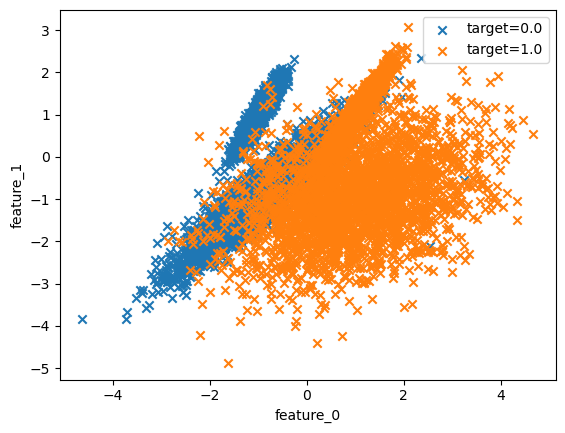

In [123]:
# ------------------------------------
# --- Generate some synthetic data ---
n_rows = 10_000
n_features = 2
n_informative = 2
n_classes = 2

features = [f"feature_{ii}" for ii in range(n_features)]
df = pd.DataFrame(
    np.column_stack(
        make_classification(
            n_samples=n_rows,
            n_features=n_features,
            n_classes=n_classes,
            n_informative=n_informative,
            n_redundant=n_features - n_informative,
            n_clusters_per_class=2,
            random_state=666,
        )
    ),
    columns=features + ["target"],
)

# ----------------------------
# --- Inspect the clusters ---
fig, ax = plt.subplots()

for target in df["target"].unique():
    subset = df[df["target"] == target].copy()
    ax.scatter(subset["feature_0"], subset["feature_1"], label=f"target={target}", marker="x")

ax.set_xlabel("feature_0")
ax.set_ylabel("feature_1")
ax.legend()
plt.show()

-----------

### Now inspect each feature individually

It is clear from these plots that one of the variables has a strong relationsghip with the target and with the log odds of the target. However, this is not clear for the second variable which shows no real relationship from this chart. If we had hundreds of variables and we were trying to filter out those that did not appear predictive using univariate plots like the ones below, then we would likely get rid of this feature, however the next section will show that this would result in worse model performance.

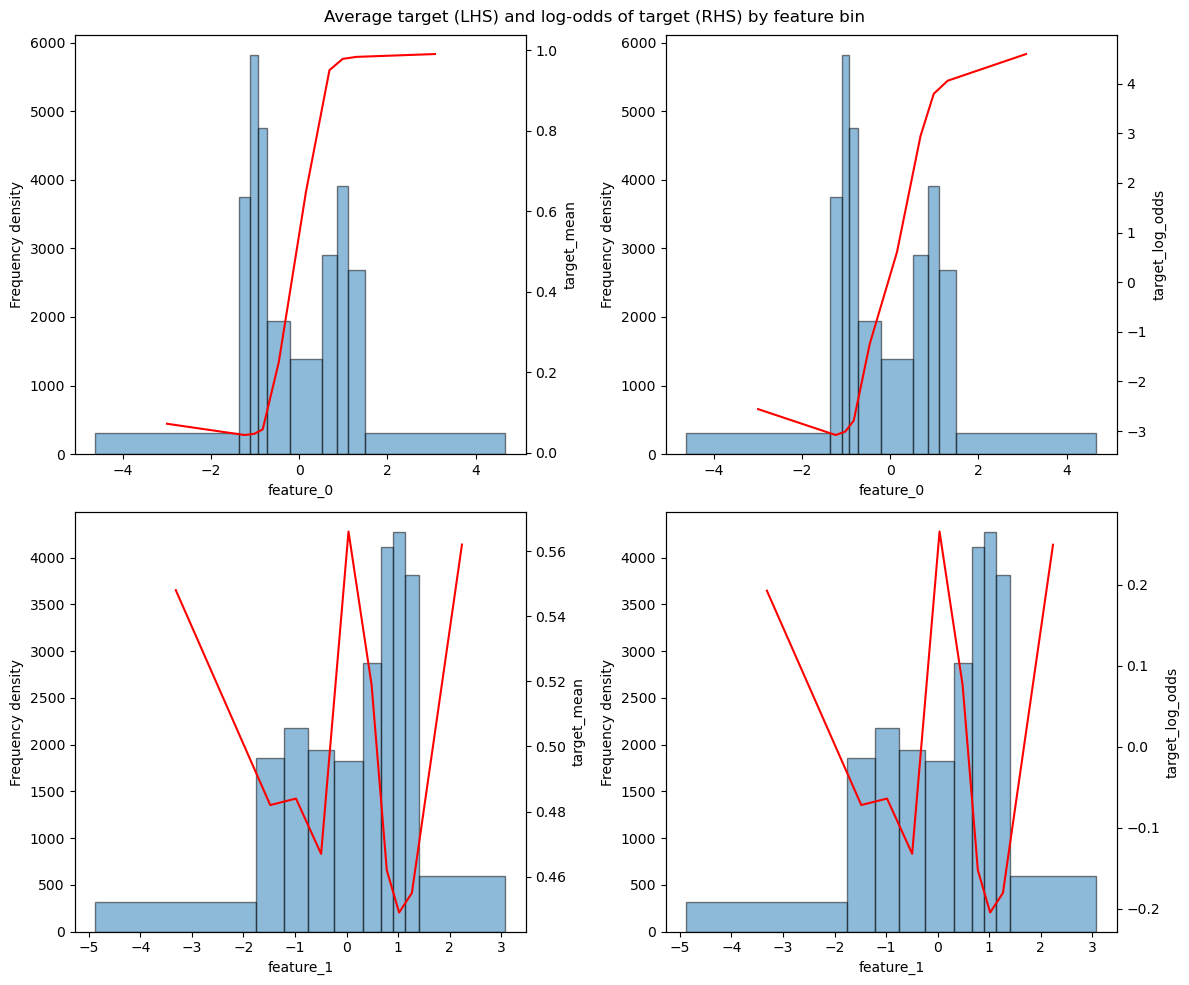

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=n_features, figsize=(12, 5*n_features))
for ii, feature in enumerate(features):
    summary = feature_summary(df, feature, "target", for_plotting=True)

    axes = ax[ii]
    fig = plot_feature(summary, feature, "target_mean", ax=axes[0])
    fig = plot_feature(summary, feature, "target_log_odds", ax=axes[1])

fig.suptitle("Average target (LHS) and log-odds of target (RHS) by feature bin")
fig.tight_layout()
fig

------

### Model training 

We now fit two models where one is trained on only `feature_0` and the other is trained on both features. We can see that `feature_1`, which appeared non-predictive from the above chart, has a statistically-significant relationship with the target and that the model trained on both features is more predictive, as measured by the area under the ROC and Precision-Recall curves.

In [140]:
# ---------------------------------------
# --- Fit a logistic regression model ---
model_single = sm.Logit(df["target"], sm.add_constant(df[["feature_0"]])).fit()
print(model_single.summary())

preds_single = model_single.predict(sm.add_constant(df[["feature_0"]]))

print("\n----------------------\nSingle-feature model performance")
pd.Series(
    [roc_auc_score(df["target"], preds_single), average_precision_score(df["target"], preds_single)],
    index=["ROC AUC", "Average Precision"],
)

Optimization terminated successfully.
         Current function value: 0.256379
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.6301
Time:                        13:52:28   Log-Likelihood:                -2563.8
converged:                       True   LL-Null:                       -6931.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2782      0.038      7.347      0.000       0.204       0.352
feature_0      2.8451      0.

ROC AUC              0.955074
Average Precision    0.960975
dtype: float64

In [139]:
model_multi = sm.Logit(df["target"], sm.add_constant(df[["feature_0", "feature_1"]])).fit()
print(model_multi.summary())

preds_multi = model_multi.predict(sm.add_constant(df[["feature_0", "feature_1"]]))

print("\n----------------------\nMulti-feature model performance")
pd.Series(
    [roc_auc_score(df["target"], preds_multi), average_precision_score(df["target"], preds_multi)],
    index=["ROC AUC", "Average Precision"],
)

Optimization terminated successfully.
         Current function value: 0.202961
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.7072
Time:                        13:52:08   Log-Likelihood:                -2029.6
converged:                       True   LL-Null:                       -6931.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1255      0.042      2.961      0.003       0.042       0.208
feature_0      3.8755      0.

ROC AUC              0.974524
Average Precision    0.974131
dtype: float64

-----------

### Visualise model predictions

Finally, we visualise the model predictions using a heatmap. We do this for both models to see what the effect of introducing the second feature is on the predictions.

We can cleaely see that the decision boundary is on a slant which allows for the model to better capture the relationship between the features and the target.

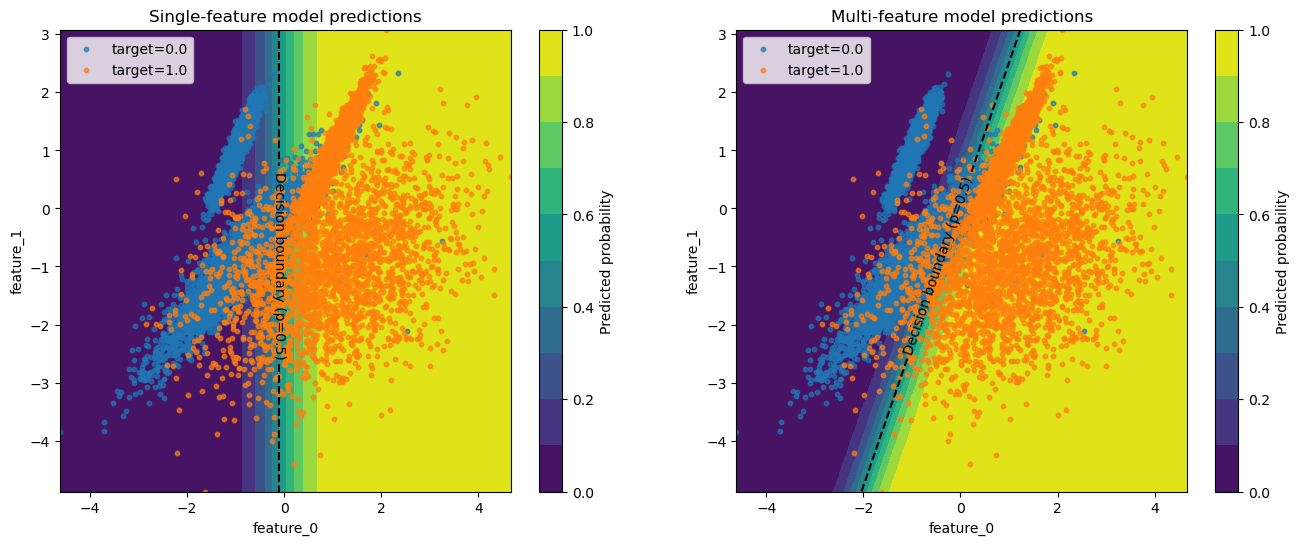

In [146]:
# -----------------------------------------------------
# --- Generate predictions across the feature space ---
feature_0_range = np.linspace(df["feature_0"].min(), df["feature_0"].max(), 50)
feature_1_range = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 50)

df_preds = pd.DataFrame(
    list(itertools.product(feature_0_range, feature_1_range)),
    columns=["feature_0", "feature_1"]
)

df_preds["preds_single"] = model_single.predict(sm.add_constant(df_preds[["feature_0"]]))
df_preds["preds_multi"] = model_multi.predict(sm.add_constant(df_preds[["feature_0", "feature_1"]]))


fig, (ax_single, ax_multi) = plt.subplots(figsize=(16, 6), ncols=2)

for ax, pred_col, title in zip(
    [ax_single, ax_multi],
    ["preds_single", "preds_multi"],
    ["Single-feature model predictions", "Multi-feature model predictions"]
):
    # reshape predictions into grid
    Z = df_preds[pred_col].values.reshape(len(feature_0_range), len(feature_1_range)).T

    # probability surface
    contour = ax.contourf(
        feature_0_range,
        feature_1_range,
        Z,
        levels=10,
    )

    # add colorbar
    cbar = plt.colorbar(contour)
    cbar.set_label("Predicted probability")

    # overlay actual data
    for target in df["target"].unique():
        subset = df[df["target"] == target]
        ax.scatter(
            subset["feature_0"],
            subset["feature_1"],
            label=f"target={target}",
            s=10,
            alpha=0.7
        )

    # decision boundary (p = 0.5)
    contour = ax.contour(
        feature_0_range,
        feature_1_range,
        Z,
        levels=[0.5],
        colors="black",
        linestyles="--",
    )
    ax.clabel(contour, fmt="Decision boundary (p=0.5)", inline=True)

    ax.set_xlabel("feature_0")
    ax.set_ylabel("feature_1")
    ax.legend()
    ax.set_title(title)

-----------

## Conclusions

Above is a good example of the dangers of performing univariate feature analysis. There are situations in which a feature may not be predictive by itself, but which "becomes" predictive when in the presence of another variable. Put into a more mathematical form, $P(y | x_{1})$ may not be predictive, but $P(y | x_{1}, x_{2})$ is strongly predictive.

To identify situations such as this we can:
- Train a logistic regression model on the entire set of features but set a high value for the regularisation parameter $\alpha$. This parameter can be used to perform feature selection automatically by getting rid of those features which are not important
- Train a tree-based model and look for the strongest interactions, e.g. by using the SHAP interaction values
- Look at some feature importance metrics (e.g. permutation importance) for a model trained on all variables

If the predictive power of variables is only via a univariate feature analysis then there will be the risk of ignoring important variables.